# Lancoz Algorithm, Ground-State: J1-J2

> **Code basé sur le tutoriel officiel de NetKet :**
> G. Carleo et F. Vicentini, *Ground-State: J1-J2 model*, NetKet Tutorials. 
> [En ligne]. Disponible : [https://netket.readthedocs.io/en/latest/tutorials/gs-j1j2.html](https://netket.readthedocs.io/en/latest/tutorials/gs-j1j2.html)

In [1]:
import tqdm as tqdm
import netket as nk
import time
import numpy as np
from tqdm import tqdm
import os
import sys
import networkx as nx
import matplotlib.pyplot as plt
import json
import jax 
jax.config.update("jax_enable_x64", True)

/Users/user/Desktop/EPFL/MA2/TPIV/project-tp/.env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can disable these tips by setting export NETKET_NO_TIPS=1 in your .bashrc.

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.lanczos_krylov import Krylov_method_with_bootstrap
from src.plot_VMC import plot_VMC, plot_energy_distribution, plot_zero_variance_extrapolation
from src.utils import save_simulation_logs

ModuleNotFoundError: No module named 'src.plot_VMC'

In [ ]:
verbose = True

## The Frustrated $J_1-J_2$ Heisenberg Model

To introduce geometric frustration and test the robustness of our Neural Network Quantum State (NQS) alongside the Lanczos method, we investigate the $J_1-J_2$ Heisenberg model on a one-dimensional chain with periodic boundary conditions. 

Unlike the standard Heisenberg model, this system includes a next-nearest-neighbor interaction. The Hamiltonian of the model is given by:

$$H = J_1 \sum_{i=1}^{L} \boldsymbol{\sigma}_i \cdot \boldsymbol{\sigma}_{i+1} + J_2 \sum_{i=1}^{L} \boldsymbol{\sigma}_i \cdot \boldsymbol{\sigma}_{i+2}$$

where:
* $L$ is the number of sites in the 1D chain.
* $\boldsymbol{\sigma}_i = (\sigma_i^x, \sigma_i^y, \sigma_i^z)$ is the vector of Pauli matrices acting on site $i$.
* $J_1$ is the nearest-neighbor coupling constant.
* $J_2$ is the next-nearest-neighbor coupling constant.

The competition between the $J_1$ and $J_2$ interactions (specifically when both are antiferromagnetic, $J_1, J_2 > 0$) introduces strong quantum frustration, destroying simple magnetic orders and giving rise to highly entangled, complex quantum phases.

*(Note: We will apply a prefactor of $0.25$ in our code to smoothly transition from the Pauli matrix formalism to the physical spin-$1/2$ operators, $\mathbf{S} = \frac{1}{2}\boldsymbol{\sigma}$.)*

In [ ]:
# Couplings J1 and J2
J2_J1 = 0.5
J = [1, J2_J1]
L = 20

# hyperparameters 
diag_shift = 1e-4           # The diagonal regularization parameter
learning_rate = 1e-2        # learning rate
n_samples = 4096            # number of samples (aug : pour avoir des stats physiques), 4096
n_iter = 50                # number of iterations # 600
alpha = 1                   # feature density. Number of features equal to alpha * input.shape[-1]
num_it = 1000               # number of iterations for the Krylov method

# data directory
data_file = f"./datas/J1_J2/datas_J1_J2_{J2_J1}_iter_{n_iter}"
dir_init = data_file + "/RBM_init"
if not os.path.exists(data_file):
    os.makedirs(data_file)
    print(f"Le dossier '{data_file}' vient d'être créé.")
else:
    print(f"Le dossier '{data_file}' existe déjà.")

if verbose :
    print(f" -> diag_shift : {diag_shift}")
    print(f" -> learning rate : {learning_rate}")
    print(f" -> # samples : {n_samples}")
    print(f" -> # iterations : {n_iter}")
    print(f" -> feature density : {alpha}")

hyperparameters = {
    "data_file": data_file,
    "dir_init": dir_init,
    "diag_shift": diag_shift,
    "learning_rate": learning_rate,
    "n_samples": n_samples,
    "n_iter": n_iter,
    "feature_density_alpha": alpha,
    "num_it": num_it,
    "J2/J1": J2_J1,
    "L": L
}
json_path = os.path.join(data_file, "hyperparameters.json")

with open(json_path, 'w') as f:
    json.dump(hyperparameters, f, indent=4) 

print(f"Paramètres sauvegardés avec succès dans {json_path}")

Le dossier './datas/datas_J1_J2_0.5_iter_50' existe déjà.
 -> diag_shift : 0.0001
 -> learning rate : 0.01
 -> # samples : 4096
 -> # iterations : 50
 -> feature density : 1
Paramètres sauvegardés avec succès dans ./datas/datas_J1_J2_0.5_iter_50/hyperparameters.json


In [ ]:
# Define custom graph
edge_colors = []
for i in range(L):
    edge_colors.append([i, (i + 1) % L, 1])
    edge_colors.append([i, (i + 2) % L, 2])

# Define the netket graph object
graph = nk.graph.Graph(edges=edge_colors)

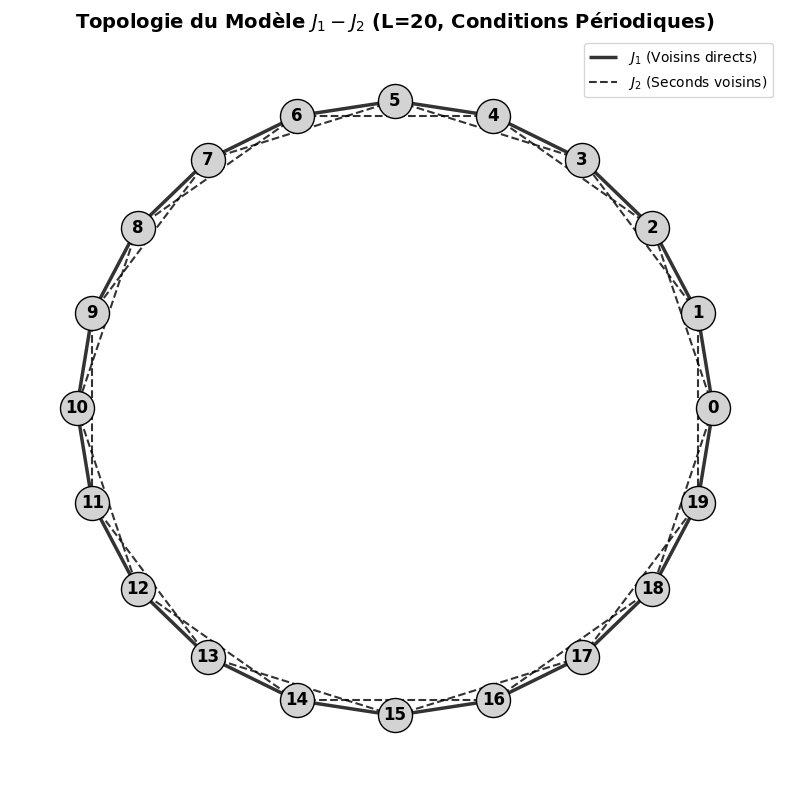

In [ ]:
if verbose:
    nx_g = graph.to_networkx()
    pos = nx.circular_layout(nx_g)

    edges_j1 = [(u, v) for u, v, d in nx_g.edges(data=True) if d['color'] == 1]
    edges_j2 = [(u, v) for u, v, d in nx_g.edges(data=True) if d['color'] == 2]

    plt.figure(figsize=(8, 8))
    nx.draw_networkx_nodes(nx_g, pos, node_size=600, node_color='lightgray', edgecolors='black')
    nx.draw_networkx_labels(nx_g, pos, font_weight='bold')
    nx.draw_networkx_edges(nx_g, pos, edgelist=edges_j1, width=2.5, alpha=0.8, label='$J_1$ (Voisins directs)')
    nx.draw_networkx_edges(nx_g, pos, edgelist=edges_j2, width=1.5, alpha=0.8, style='dashed', label='$J_2$ (Seconds voisins)')
    plt.title(f"Topologie du Modèle $J_1-J_2$ (L={L}, Conditions Périodiques)", fontsize=14, fontweight='bold')
    plt.legend(loc="upper right")
    plt.axis('off') # Cache les axes
    plt.tight_layout()
    plt.show()

In [ ]:
# Sigma^z*Sigma^z interactions
sigmaz = [[1, 0], [0, -1]]
mszsz = np.kron(sigmaz, sigmaz)

# Exchange interactions
exchange = np.asarray([[0, 0, 0, 0], [0, 0, 2, 0], [0, 2, 0, 0], [0, 0, 0, 0]])

bond_operator = [
    (J[0] * mszsz).tolist(),
    (J[1] * mszsz).tolist(),
    (-J[0] * exchange).tolist(),
    (J[1] * exchange).tolist(),
]

bond_color = [1, 2, 1, 2]

In [ ]:
# Defining the Hamiltonian
hi = nk.hilbert.Spin(s=0.5, total_sz=0.0, N=graph.n_nodes) # Spin based Hilbert Space
ha = 0.25 * nk.operator.GraphOperator(
    hi, graph=graph, bond_ops=bond_operator, bond_ops_colors=bond_color
)

In [ ]:
# Exact Diagonalization
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print("The exact ground-state energy is E0=", exact_gs_energy)

print(exact_gs_energy/L)

The exact ground-state energy is E0= -7.500000000000014
-0.3750000000000007


In [ ]:
# Learning with a Restricted Boltzmann Machine (RBM)
model = nk.models.RBM(alpha=alpha, param_dtype=np.complex128)
sampler = nk.sampler.MetropolisExchange(hilbert=hi, graph=graph)
optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)
vs = nk.vqs.MCState(sampler, model, n_samples=n_samples)
gs = nk.driver.VMC_SR(
    hamiltonian=ha, 
    optimizer=optimizer, 
    diag_shift=diag_shift, 
    variational_state=vs
)

gs.run(out=data_file + "/VMC_datas", n_iter=n_iter)

Automatic SR implementation choice:  QGT


100%|██████████| 50/50 [00:15<00:00,  3.18it/s, Energy=-7.008+0.001j ± 0.012 [σ²=3.8e-01, R̂=1.001]]


(JsonLog('./datas/datas_J1_J2_0.5_iter_50/VMC_datas', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.025582551956176758
   	Params: 0.015902042388916016,)

Figure saved as ./datas/datas_J1_J2_0.5_iter_50/RBM_energy_convergence.png


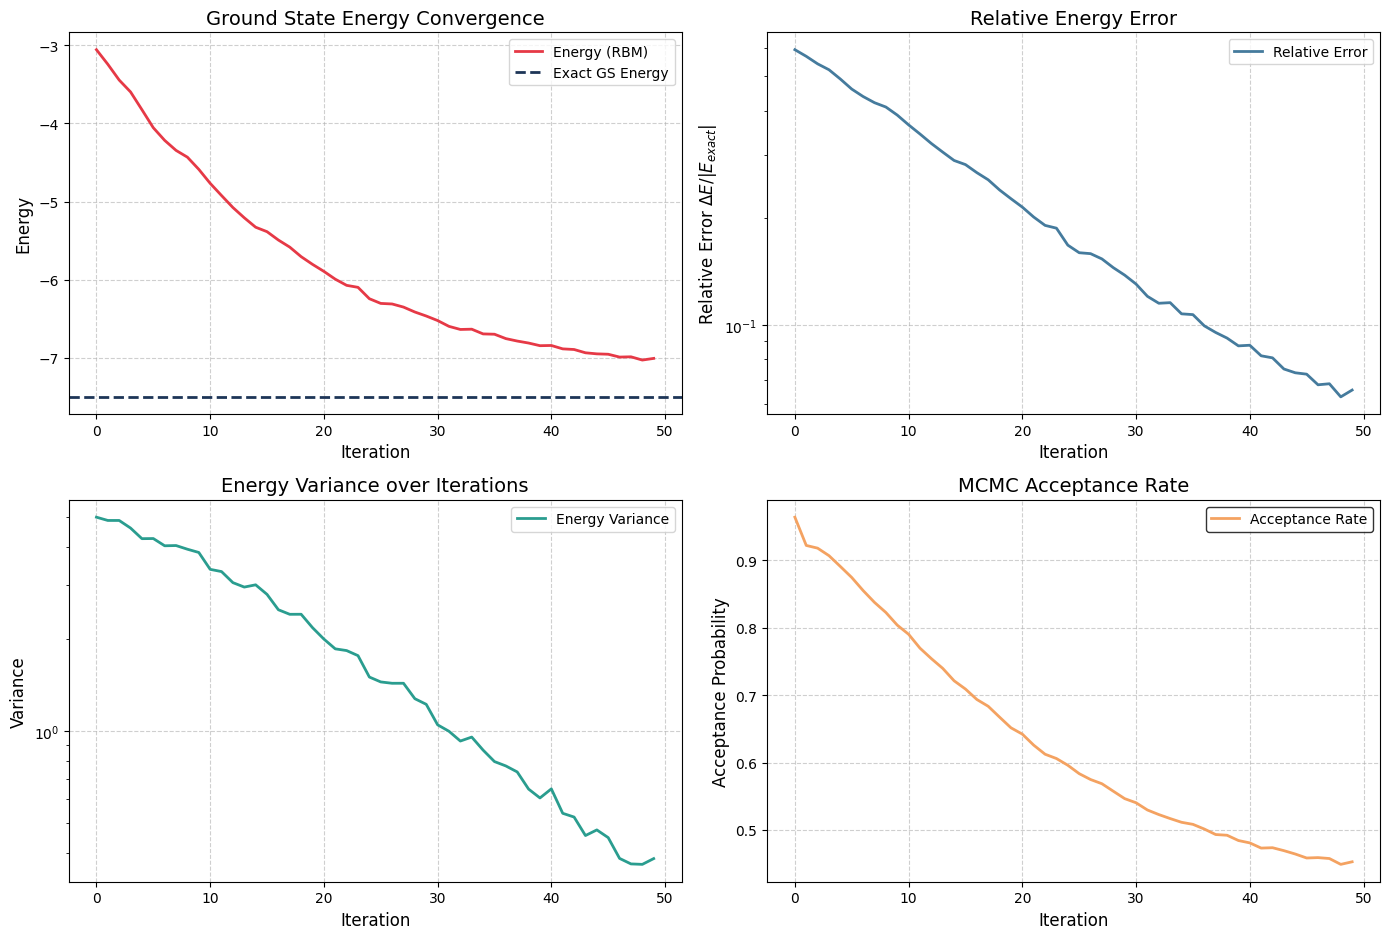

True

In [ ]:
plot_VMC(data_file + "/VMC_datas.log", exact_gs_energy, save_fig=True, fig_name=f"{data_file}/RBM_energy_convergence.png")

In [ ]:
results_eL = np.zeros(num_it)
results_e0 = np.zeros(num_it)
results_sigma_e0 = np.zeros(num_it) 
results_sigma_eL = np.zeros(num_it)
results_time = np.zeros(num_it) 

pbar = tqdm(range(num_it))

start_time_global = time.perf_counter()

for i in pbar:

    vs.sample() 
    
    el, e0, sigma_e0, sigma_eL = Krylov_method_with_bootstrap(
        vs, ha
    )

    elapsed_time = time.perf_counter() - start_time_global
    
    results_eL[i] = el
    results_e0[i] = e0
    results_sigma_e0[i] = sigma_e0
    results_sigma_eL[i] = sigma_eL
    results_time[i] = elapsed_time

    pbar.set_postfix(el=f"{el:.5f} ± {sigma_eL:.5f}", exact=f"{exact_gs_energy:.5f}")


el_valides = results_eL[~np.isnan(results_eL)]

if verbose :
    print(f"Mean of the means (E0) : {np.mean(results_e0):.8f}")
    print(f"Std of the means (E0)  : {np.std(results_e0, ddof=1):.8f}")
    print(f"Mean  (EL)             : {np.mean(el_valides):.8f}")
    print(f"Std (EL)               : {np.std(el_valides, ddof=1):.8f}")
    print(f"Exact Energy           : {exact_gs_energy}")

100%|██████████| 1000/1000 [1:18:28<00:00,  4.71s/it, el=-7.21108 ± 0.25904, exact=-7.50000]

Mean of the means (E0) : -7.03178858
Std of the means (E0)  : 0.01068213
Mean  (EL)             : -7.24807158
Std (EL)               : 0.01508147
Exact Energy           : -7.500000000000014


In [ ]:
save_simulation_logs(
    target_dir=data_file,
    n_iterations=num_it,          
    e0_array=results_e0,      
    sigma_e0_array=results_sigma_e0, 
    el_array=results_eL,         
    sigma_el_array=results_sigma_eL,
    time_array=results_time,
    exact_energy=exact_gs_energy
)

Simulation logs successfully saved to: ./datas/datas_J1_J2_0.5_iter_50/simulation_results.json


Graphique sauvegardé sous : ./datas/datas_J1_J2_0.5_iter_50/distribution_energies_krylov.png


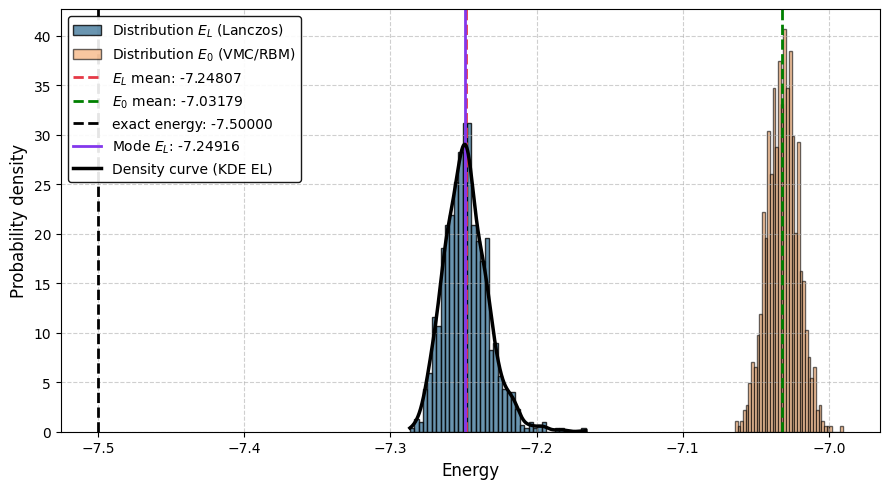

In [ ]:
plot_energy_distribution(
    el_valides=el_valides, 
    results_e0=results_e0, 
    exact_gs_energy=exact_gs_energy, 
    data_file=data_file,
    bins=40 
)

Graphique d'extrapolation sauvegardé sous : ./datas/datas_J1_J2_0.5_iter_50/extrapolation_plot.png


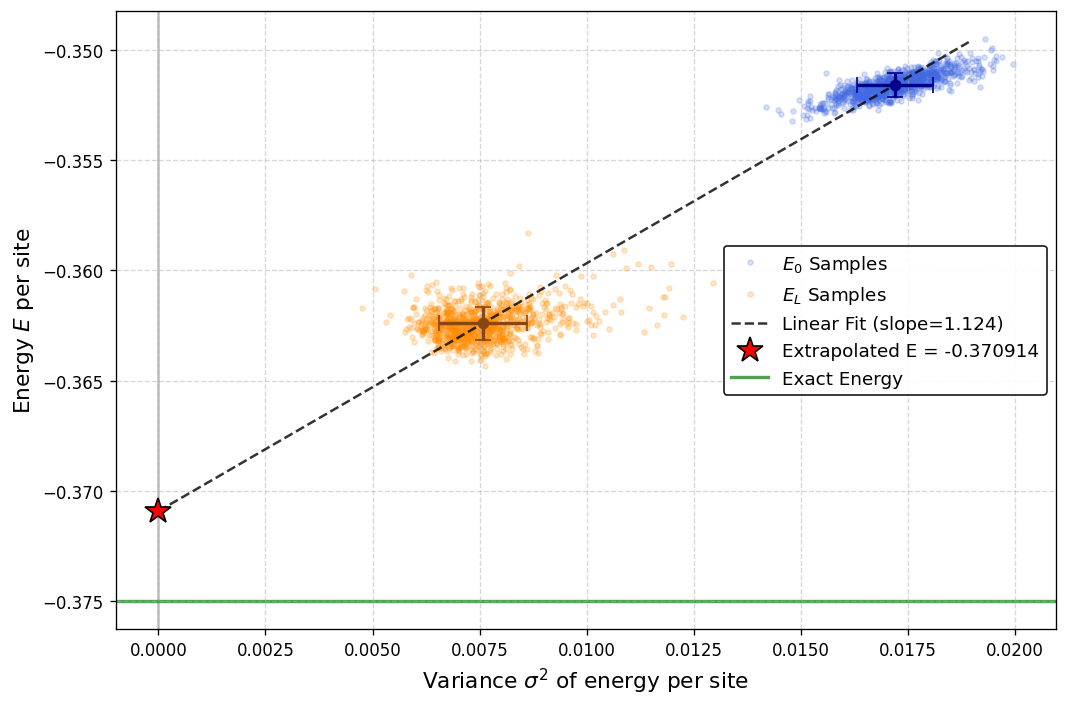


--- Extrapolation Results (per site) ---
Extrapolated Energy (x=0) : -0.37091350
Exact Energy              : -0.37500000
Absolute Error            : 4.08649881e-03
----------------------------------------



In [ ]:
plot_zero_variance_extrapolation(
    results_e0 = results_e0, 
    results_sigma_e0 = results_sigma_e0, 
    el_valides = el_valides, 
    results_sigma_eL = results_sigma_eL, 
    exact_gs_energy = exact_gs_energy, 
    L = L, 
    data_file = data_file
)